# Promoter Reporter Analysis

This notebook analyzes fluorescence intensity data from promoter reporter experiments comparing control and pSEVA conditions.

**Analysis includes:**
- Loading fluorescence intensity data from multiple positions
- Statistical comparison between conditions (Mann-Whitney U or t-test)
- Visualization of GFP and mCherry intensities with significance testing

**Output:**
- `2SB_scatter.pdf`: Scatter plot with mean bars and statistical significance

## Import Libraries

In [12]:
import pathlib
import pandas as pd

## Define Data Loading Function

Function to load fluorescence intensity data from each position folder and aggregate statistics

In [13]:
def load_condition(root_path, condition_name):
    rows = []

    pos_folders = sorted(
        [p for p in root_path.glob("pos*") if p.is_dir()]
    )

    for pos in pos_folders:
        csv_path = pos / "phase" / "fluo_intensities.csv"
        if not csv_path.exists():
            continue

        df_pos = pd.read_csv(csv_path)

        rows.append({
            "condition": condition_name,
            "pos": pos.name,
            "raw_gfp_intensity": df_pos["intensity_raw_gfp"].mean(),
            "mcherry_raw_intensity": df_pos["intensity_raw_mcherry"].mean(),
            "n_cells": len(df_pos)
        })

    return pd.DataFrame(rows)


## Load Data

Load fluorescence intensity data for control and pSEVA conditions from the Image_Data directory

In [14]:
# Define relative paths to Image_Data directory (3 levels up from Figure_Data/Figure1/S2_promoter_reporter)
image_data_root = pathlib.Path("../../../Image_Data/Figure1/S2_promoter_reporter")

paths = {
    "control": image_data_root / "control",
    "pSEVA": image_data_root / "pSEVA",
}

# Load data for each condition
df_control = load_condition(paths["control"], "control")
df_pseva = load_condition(paths["pSEVA"], "pSEVA")

# Combine into single dataframe
df = pd.concat([df_control, df_pseva], ignore_index=True)

print(f"Loaded {len(df_control)} control positions and {len(df_pseva)} pSEVA positions")
print(f"Total cells: control={df_control['n_cells'].sum()}, pSEVA={df_pseva['n_cells'].sum()}")

Loaded 9 control positions and 10 pSEVA positions
Total cells: control=4215, pSEVA=5733


## Statistical Analysis and Visualization

Perform statistical comparison between conditions and generate publication-quality scatter plot with significance indicators


STATISTICAL COMPARISON: control vs pSEVA

mCherry:
  control: 328.8 ± 3.2 (n=9)
  pSEVA:   627.9 ± 25.6 (n=10)
  Test: Mann-Whitney U
  p-value: 0.0003 ***
  Effect size: Median Δ = -305.7

GFP:
  control: 324.2 ± 3.9 (n=9)
  pSEVA:   586.6 ± 5.2 (n=10)
  Test: t-test
  p-value: 0.0000 ***
  Effect size: Cohen's d = -18.29


Figure saved as: 2SB_scatter.pdf


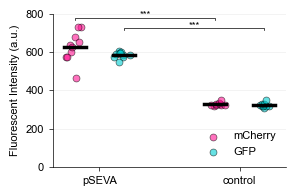

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib
from scipy.stats import mannwhitneyu, ttest_ind, shapiro

# ============================================================================
# PLOTTING CONFIGURATION (Chartosaur style)
# ============================================================================
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 8

# ============================================================================
# ANALYSIS CONFIGURATION
# ============================================================================
conditions = ["pSEVA", "control"]  # Order for plotting (left to right)
channels = [
    {"col": "mcherry_raw_intensity", "label": "mCherry", "color": '#FF1493'},
    {"col": "raw_gfp_intensity", "label": "GFP", "color": '#00CED1'}
]

# ============================================================================
# STATISTICAL COMPARISON FUNCTION
# ============================================================================
def compare_two_groups(df, value_col, cond1="control", cond2="pSEVA"):
    """
    Compare two experimental conditions using appropriate statistical test.
    
    Uses Shapiro-Wilk test to check normality, then applies:
    - Student's t-test if both groups are normally distributed (n ≥ 5)
    - Mann-Whitney U test otherwise (non-parametric alternative)
    
    Parameters:
        df: DataFrame with 'condition' column and value column
        value_col: Column name containing measurements
        cond1, cond2: Condition labels to compare
        
    Returns:
        Dictionary with test statistics, p-value, effect size, and group statistics
    """
    
    # Extract data for each group
    group1 = df.loc[df["condition"] == cond1, value_col].dropna().values
    group2 = df.loc[df["condition"] == cond2, value_col].dropna().values
    
    n1, n2 = len(group1), len(group2)
    
    # Check normality assumption (Shapiro-Wilk test)
    if n1 >= 3 and n2 >= 3:
        _, p1 = shapiro(group1)
        _, p2 = shapiro(group2)
        normal = (p1 > 0.05) and (p2 > 0.05)  # Both groups should be normal
    else:
        normal = False
    
    # Choose appropriate statistical test
    if normal and n1 >= 5 and n2 >= 5:
        # Parametric test: Student's t-test
        stat, p_val = ttest_ind(group1, group2)
        
        # Calculate Cohen's d (standardized effect size)
        pooled_std = np.sqrt(((n1-1)*np.var(group1, ddof=1) + 
                              (n2-1)*np.var(group2, ddof=1)) / (n1+n2-2))
        cohens_d = (np.mean(group1) - np.mean(group2)) / pooled_std
        
        test = "t-test"
        effect = f"Cohen's d = {cohens_d:.2f}"
    else:
        # Non-parametric test: Mann-Whitney U
        stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')
        median_diff = np.median(group1) - np.median(group2)
        
        test = "Mann-Whitney U"
        effect = f"Median Δ = {median_diff:.1f}"
    
    # Assign significance level
    if p_val < 0.001:
        sig = "***"
    elif p_val < 0.01:
        sig = "**"
    elif p_val < 0.05:
        sig = "*"
    else:
        sig = "ns"
    
    return {
        'test': test,
        'p': p_val,
        'sig': sig,
        'effect': effect,
        'n1': n1,
        'n2': n2,
        'mean1': np.mean(group1),
        'mean2': np.mean(group2),
        'sem1': np.std(group1, ddof=1) / np.sqrt(n1),
        'sem2': np.std(group2, ddof=1) / np.sqrt(n2)
    }

# ============================================================================
# RUN STATISTICAL TESTS
# ============================================================================
print("\n" + "="*60)
print("STATISTICAL COMPARISON: control vs pSEVA")
print("="*60)

results = {}
for ch in channels:
    res = compare_two_groups(df, ch['col'])
    results[ch['label']] = res
    
    print(f"\n{ch['label']}:")
    print(f"  control: {res['mean1']:.1f} ± {res['sem1']:.1f} (n={res['n1']})")
    print(f"  pSEVA:   {res['mean2']:.1f} ± {res['sem2']:.1f} (n={res['n2']})")
    print(f"  Test: {res['test']}")
    print(f"  p-value: {res['p']:.4f} {res['sig']}")
    print(f"  Effect size: {res['effect']}")

print("\n" + "="*60 + "\n")

# ============================================================================
# CREATE PUBLICATION-QUALITY FIGURE
# ============================================================================
fig, ax = plt.subplots(figsize=(3, 2))
x = np.arange(len(conditions))
strip_width = 0.35

# Plot each fluorescence channel
for ch_idx, ch in enumerate(channels):
    value_col = ch["col"]
    x_pos = x + (ch_idx - 0.5) * strip_width
    
    # Plot individual data points with jitter
    for i, cond in enumerate(conditions):
        y = df.loc[df["condition"] == cond, value_col].values
        jitter = np.random.normal(x_pos[i], 0.03, size=len(y))
        ax.scatter(jitter, y, alpha=0.6, s=25, color=ch["color"], 
                   edgecolors='black', linewidths=0.5, zorder=1, 
                   label=ch["label"] if i == 0 else "")
    
    # Add mean bars
    means = df.groupby("condition")[value_col].mean().loc[conditions].values
    for i, mean_val in enumerate(means):
        ax.plot([x_pos[i] - 0.08, x_pos[i] + 0.08], [mean_val, mean_val], 
                color='black', linewidth=2.5, zorder=2)
    
    # Add significance brackets and labels
    y_max = df[value_col].max()
    y_bracket = y_max * (1.05 + ch_idx * 0.13)
    
    x_left, x_right = x_pos[0], x_pos[1]
    ax.plot([x_left, x_left, x_right, x_right], 
            [y_bracket, y_bracket*1.01, y_bracket*1.01, y_bracket],
            'k-', linewidth=0.5)
    
    # Add significance indicator
    sig_text = results[ch['label']]['sig']
    ax.text((x_left + x_right)/2, y_bracket*1, sig_text, 
            ha='center', va='bottom', fontsize=7)

# Apply Chartosaur styling
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontname='Arial', fontsize=8)
ax.set_ylabel('Fluorescent Intensity (a.u.)', fontname='Arial', fontsize=8)
ax.tick_params(axis='both', which='major', labelsize=8, width=0.5, length=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.yaxis.grid(True, alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, loc='lower right', fontsize=8, prop={'family': 'Arial'})

plt.tight_layout()
plt.savefig('2SB_scatter.pdf', dpi=300, bbox_inches='tight')
print("Figure saved as: 2SB_scatter.pdf")
plt.show()